<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [299]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from typing import Literal

from matplotlib import cm
from scipy.linalg import eigh
from scipy.sparse import diags
from scipy import special
from scipy.special import gammaln

matplotlib.rcParams['animation.embed_limit'] = 50.0  # значение в мегабайтах

In [300]:
n = 50 # размер матриц, размер гильбертова пространства
N = 250
m = 1 # не трогать
h = 1 # не трогать
l = 6 # не трогать
K = 1 # коэффициент связи между осцилляторами
omega1 = 1
omega2 = 1.5
omegas = tuple([omega1, omega2])
koeff = h/(2*m*40) # не трогать
a_birth = np.diag(np.array([np.sqrt(i) for i in range(1, n)]), k = -1)

a_destroy =np.diag(np.array([np.sqrt(i) for i in range(1, n)]), k = 1)

E = np.eye(n)

In [301]:
def hamilton_fock(linearity: Literal["linear", "nonlinear"], omega: float = 1.0):

  global a_birth, a_destroy, E, koeff, m, h

  x_sum = (a_destroy + a_birth)/np.sqrt(2 * omega)

  #x_razn = a_birth - a_destroy

  H_0 = h * omega * (a_birth @ a_destroy + 0.5 * E)

  if linearity == "linear":
    return H_0
  else:
    H_i = np.power(koeff/omega, 2) * (x_sum @ x_sum) @ (x_sum @ x_sum)
    return H_0 + H_i

In [302]:
def hamilton_fock_sviaz(linearity: Literal["linear", "nonlinear"], omegas: tuple = (1.0, 1.5)):
  global a_birth, a_destroy, E, koeff, m, h, K

  x_sum_1 = (a_destroy + a_birth)/np.sqrt(2 * omegas[0])
  x_sum_2 = (a_destroy + a_birth)/np.sqrt(2 * omegas[1])

  H = np.kron(hamilton_fock(linearity, omegas[0]), E) + np.kron(E, hamilton_fock(linearity, omegas[1])) + K * np.kron(x_sum_1, x_sum_2)
  return H

In [303]:
def hermite_polynomial(n_, x):
    """Полиномы Эрмита"""
    return special.hermite(n_, monic=False)(x)
def harmonic_oscillator_wf(n_, x, m=1, omega=1):
    """
    Волновая функция гармонического осциллятора
    φ_n(x) = (1/√(π 2^n n!))^(1/2) * H_n(√(mω/ℏ)x) * exp(-mωx²/2ℏ)
    """
    # В атомных единицах ℏ = 1
    h_bar = 1
    alpha = np.sqrt(m * omega / h_bar)
    xi = alpha * x

    # Нормировочная константа (вычисляется безопасно)
    if n_ == 0:
        norm = (alpha / np.pi)**0.25
    else:
        # Для больших n используем логарифмы
        log_norm = -0.5 * (n_ * np.log(2) + gammaln(n_ + 1)) + 0.5 * np.log(alpha / np.sqrt(np.pi))
        norm = np.exp(log_norm)
    #norm = 1.0 / np.sqrt(2**n * special.factorial(n)) * (alpha / np.pi)**0.25
    # Волновая функция
    phi = norm * hermite_polynomial(n_, xi) * np.exp(-xi**2 / 2)

    return phi

In [304]:
def fock_to_coordinate_2d(psi_fock, omegas, x_grid):
    global n, m

    # Количество точек сетки
    nx = len(x_grid)
    n_states = psi_fock.shape[1]

    # Предвычисляем базисные функции для каждого осциллятора
    basis1 = np.zeros((nx, n))
    basis2 = np.zeros((nx, n))
    for ni in range(n):
        basis1[:, ni] = harmonic_oscillator_wf(ni, x_grid, m, omegas[0])
        basis2[:, ni] = harmonic_oscillator_wf(ni, x_grid, m, omegas[1])

    # Подготовим массив для результатов
    psi_coord = np.zeros((n_states, nx, nx), dtype=complex)

    for k in range(n_states):
        # Извлекаем коэффициенты для k-го состояния и преобразуем в матрицу n×n
        coeff = psi_fock[:, k].reshape((n, n), order='C')   # coeff[i, j] = c_{i,j}
        # Вычисляем волновую функцию на сетке: basis1 @ coeff @ basis2.T
        psi_coord[k] = basis1 @ coeff @ basis2.T

    dx = X_fock[1] - X_fock[0]
    for i in range(min(3, Psi_fock_coordinate.shape[0])):
        norm = np.trapezoid(np.trapezoid(np.abs(Psi_fock_coordinate[i])**2, dx=dx, axis=1), dx=dx)
        print(f"Состояние {i}: ∫∫ |ψ|² dx1 dx2 = {norm:.2f}")

    return psi_coord

In [305]:
def solve_fok_basis(tasks):

  global a_birth, a_destroy, x_sum, x_razn, E, koeff, m, h, n, l, N

  h_fock = hamilton_fock_sviaz(linearity=tasks[0][1], omegas=tasks[0][0])

  # Диагонализация
  e_fock, psi_fock = eigh(h_fock)

  # Для визуализации создаем координатную сетку
  x_visual = np.linspace(-l, l, N)

  psi_fock_coordinate = fock_to_coordinate_2d(psi_fock=psi_fock, x_grid=x_visual, omegas=tasks[0][0])

  return e_fock, psi_fock_coordinate, x_visual

In [306]:
parameters = [(omegas, "nonlinear")] # одно значение

E_fock, Psi_fock_coordinate, X_fock = solve_fok_basis(tasks=parameters)

Состояние 0: ∫∫ |ψ|² dx1 dx2 = 0.014103
Состояние 1: ∫∫ |ψ|² dx1 dx2 = 0.005737
Состояние 2: ∫∫ |ψ|² dx1 dx2 = 0.013359
Состояние 3: ∫∫ |ψ|² dx1 dx2 = 0.020481
Состояние 4: ∫∫ |ψ|² dx1 dx2 = 0.038013
Состояние 5: ∫∫ |ψ|² dx1 dx2 = 0.033272
Состояние 6: ∫∫ |ψ|² dx1 dx2 = 0.205232
Состояние 7: ∫∫ |ψ|² dx1 dx2 = 0.231677
Состояние 8: ∫∫ |ψ|² dx1 dx2 = 0.928803
Состояние 9: ∫∫ |ψ|² dx1 dx2 = 0.935645
Состояние 10: ∫∫ |ψ|² dx1 dx2 = 0.971710
Состояние 11: ∫∫ |ψ|² dx1 dx2 = 0.968045
Состояние 12: ∫∫ |ψ|² dx1 dx2 = 0.983015
Состояние 13: ∫∫ |ψ|² dx1 dx2 = 0.978695
Состояние 14: ∫∫ |ψ|² dx1 dx2 = 0.984956
Состояние 15: ∫∫ |ψ|² dx1 dx2 = 0.987348
Состояние 16: ∫∫ |ψ|² dx1 dx2 = 0.990843
Состояние 17: ∫∫ |ψ|² dx1 dx2 = 0.987658
Состояние 18: ∫∫ |ψ|² dx1 dx2 = 0.994075
Состояние 19: ∫∫ |ψ|² dx1 dx2 = 0.988452
Состояние 20: ∫∫ |ψ|² dx1 dx2 = 0.996066
Состояние 21: ∫∫ |ψ|² dx1 dx2 = 0.989260
Состояние 22: ∫∫ |ψ|² dx1 dx2 = 0.990092
Состояние 23: ∫∫ |ψ|² dx1 dx2 = 0.997273
Состояние 24: ∫∫ |ψ|² dx1 

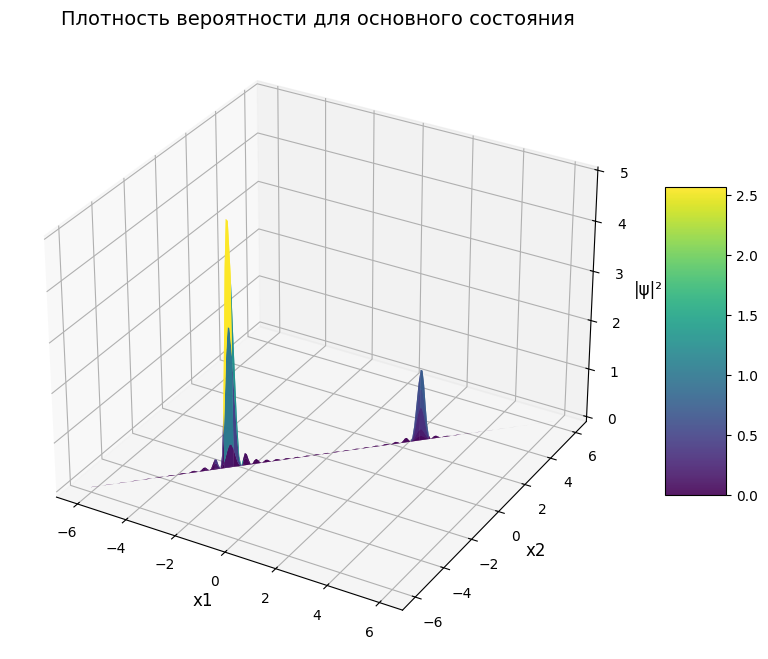

In [312]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_fock, X_fock, np.abs(Psi_fock_coordinate[30])**2, cmap=cm.viridis, alpha=0.9, linewidth=0, antialiased=True)

# Настройка осей и меток
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('|ψ|²', fontsize=12)
ax.set_title('Плотность вероятности для основного состояния', fontsize=14)

# Добавляем цветовую шкалу
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

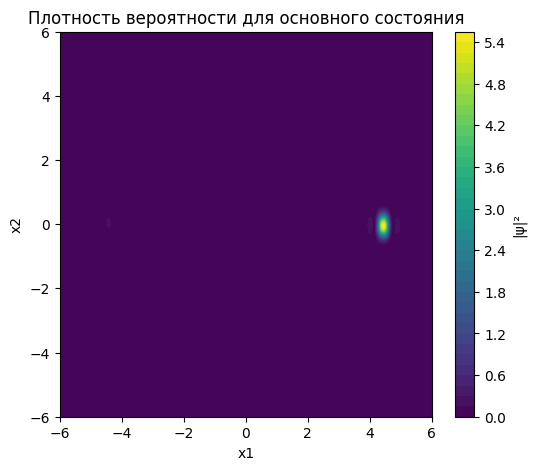

In [313]:
# Визуализация, например, для первого состояния
plt.figure(figsize=(6,5))
plt.contourf(X_fock, X_fock, np.abs(Psi_fock_coordinate[16])**2, levels=50, cmap='viridis')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(label='|ψ|²')
plt.title('Плотность вероятности для основного состояния')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: x and y must have same first dimension, but have shapes (250,) and (2500, 250)

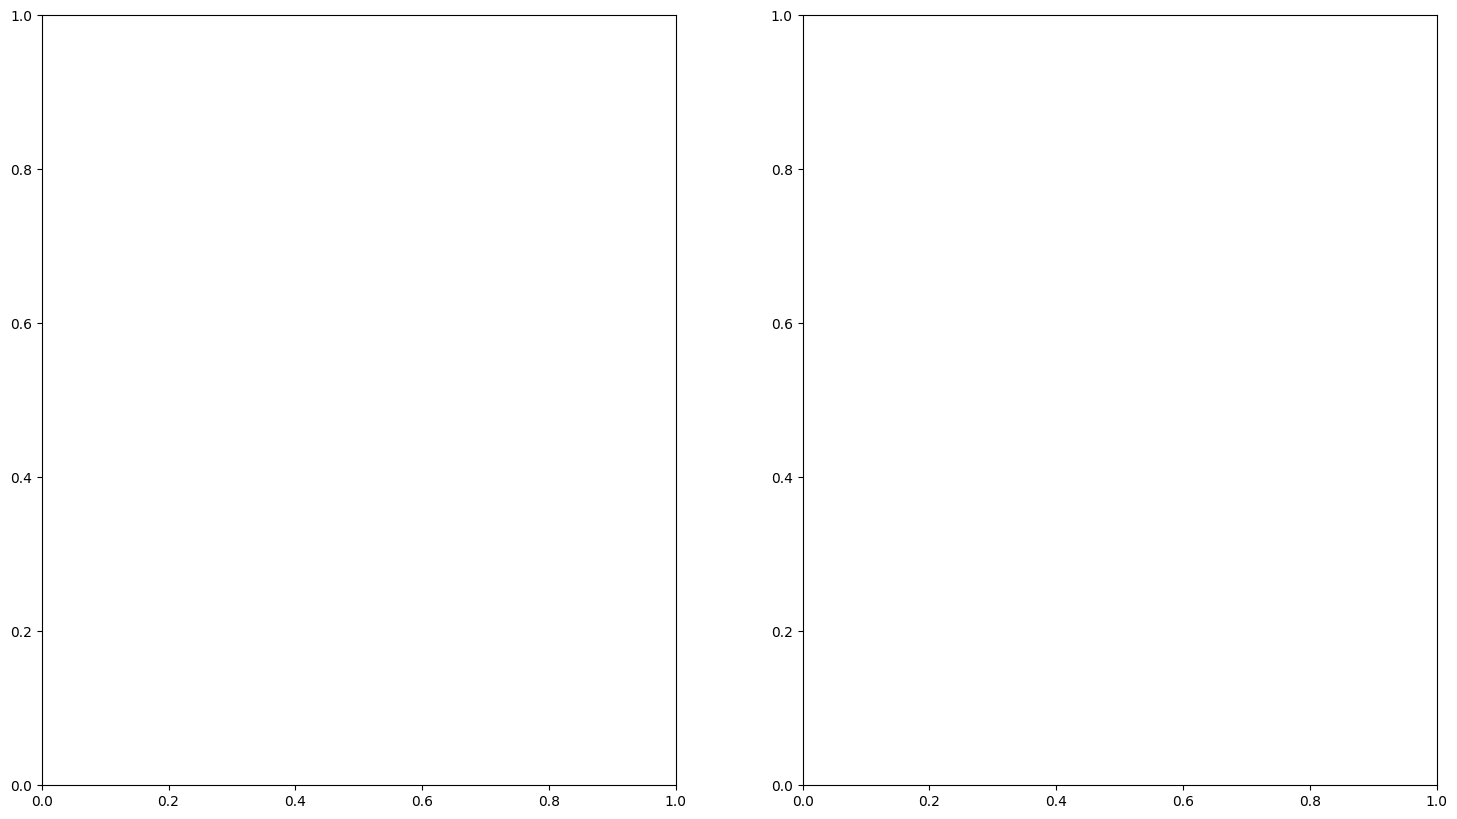

In [310]:

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Графики вероятностей
ax1 = axes[0]
ax1.plot(X_fock, Psi_fock_coordinate[:, 0]**2, 'r--', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('|ψ(x)|²')
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Графики вероятностей')

# Графики волновых функций
ax2 = axes[1]
ax2.plot(X_fock, Psi_fock_coordinate[:, 0], 'r--', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('ψ(x)')
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Волновая функция')

plt.tight_layout()
plt.show()